# Helpers

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pypsa
import country_converter as coco
from collections import Counter
import os
import country_converter

rename_map = {
    # clean
    "nuclear": "clean",
    "uranium": "clean",
    "adv_firm_tech": "clean",

    # co2
    "co2": "co2",
    "co2 sequestered": "co2",
    "co2 stored": "co2",

    # electricity
    "electricity": "electricity",

    # electricity grid
    "AC": "electricity grid",
    "DC": "electricity grid",
    "electricity distribution grid": "electricity grid",
    "low voltage": "electricity grid",

    # EV
    "BEV charger": "EV",
    "EV battery": "EV",
    "land transport EV": "EV",

    # fossil
    "CCGT": "fossil",
    "OCGT": "fossil",
    "coal": "fossil",
    "gas": "fossil",
    "lignite": "fossil",
    "oil": "fossil",
    "oil primary": "fossil",

    # GoO
    "GoO": "GoO",
    "virtual adv_firm_tech": "GoO",
    "virtual green_ocgt": "GoO",
    "virtual offwind-ac": "GoO",
    "virtual offwind-dc": "GoO",
    "virtual offwind-float": "GoO",
    "virtual onwind": "GoO",
    "virtual solar": "GoO",
    "virtual solar rooftop": "GoO",
    "virtual solar-hsat": "GoO",
    "virtual H2 Store": "GoO",
    "virtual iron-air": "GoO",
    "virtual li-ion": "GoO",

    # renewables
    "green_ocgt": "renewables",
    "hydro": "renewables",
    "offwind-ac": "renewables",
    "offwind-dc": "renewables",
    "offwind-float": "renewables",
    "onwind": "renewables",
    "ror": "renewables",
    "solar": "renewables",
    "solar rooftop": "renewables",
    "solar-hsat": "renewables",

    # storage
    "H2": "storage",
    "H2 Electrolysis": "storage",
    "H2 Fuel Cell": "storage",
    "H2 Store": "storage",
    "H2 tank": "storage",
    "H2 turbine": "storage",
    "PHS": "storage",
    "home battery": "storage",
    "home battery charger": "storage",
    "home battery discharger": "storage",
    "iron-air": "storage",
    "iron-air charger": "storage",
    "iron-air discharger": "storage",
    "li-ion": "storage",
    "li-ion charger": "storage",
    "li-ion discharger": "storage",
}

category_colors = {
    "EV": "#baf238",              # matches BEV / EV battery theme (bright lime-green)
    "GoO": "#46caf0",             # close to ammonia/NH3 + certification-style "blue"
    "clean": "#ff8c00",           # matches nuclear/uranium (clean baseload)
    "co2": "#f29dae",             # matches co2 family (soft pink)
    "electricity grid": "#97ad8c",# matches distribution grid / low voltage
    "fossil": "#545454",          # coal baseline grey (neutral fossil indicator)
    "renewables": "#235ebc",      # wind blue (iconic renewable color)
    "storage": "#ace37f"          # battery green (unifying storage theme)
}

grouping_storage = {
    "H2": "H2",
    "H2 Electrolysis": "H2",
    "H2 Fuel Cell": "H2",
    "H2 Store": "H2",
    "H2 tank": "H2",
    "H2 turbine": "H2",
    "home battery": "home battery",
    "home battery charger": "home battery",
    "home battery discharger": "home battery",
    "iron-air": "iron-air",
    "iron-air charger": "iron-air",
    "iron-air discharger": "iron-air",
    "li-ion": "li-ion",
    "li-ion charger": "li-ion",
    "li-ion discharger": "li-ion",
    "BEV charger": "EV",
    "EV battery": "EV",
    "land transport EV": "EV",
}

def prepare_network(n, year):

    # Fill missing colors
    append_color = {
        '':'#aaaaaa', 
        'none':'#aaaaaa',
        'H2 tank':'#bf13a0', 
        'H2 tank Electrolysis':'#bf13a0',
        'H2 tank Fuel Cell':'#bf13a0',
        'adv_firm_tech':'#d19D00', 
        'green_ocgt':'#2fb537', 
        'virtual adv_firm_tech':'#d19D00',
        'virtual green_ocgt':'#2fb537', 
        'iron-air':"grey",
        'iron-air charger':"grey",
        'iron-air discharger':"grey",
        'virtual iron-air':"grey",
    }

    for key, value in append_color.items():
        n.carriers.loc[key,"color"] = value

    # Change snapshotdate to year
    for c in n.components:
        for table in c.dynamic:
            c.dynamic[table].index = c.dynamic[table].index.map(lambda x: x.replace(year=year))
    
    n.snapshots = n.snapshots.map(lambda x: x.replace(year=year))

    return n
    

def strip_network_GoO(n):
    m = n.copy()
    
    nodes_to_keep = m.buses[m.buses.carrier == "GoO"].index
    m.remove("Bus", m.buses.index.symmetric_difference(nodes_to_keep))
    
    carrier_to_keep = list(m.carriers.filter(like="virtual", axis=0).index)
    carrier_to_keep.append("GoO")
    
    for c in n.components:
        if c.name not in ["Generator", "Link", "Line", "Store", "StorageUnit", "Load"]:
            continue
        
        if c.name in ["Link", "Line"]:
            location_boolean = c.static.bus0.isin(nodes_to_keep) & c.static.bus1.isin(
                nodes_to_keep
            )
        else:
            location_boolean = c.static.bus.isin(nodes_to_keep)
        to_keep = c.static.index[location_boolean & c.static.carrier.isin(carrier_to_keep)]
        to_drop = c.static.index.symmetric_difference(to_keep)
        m.remove(c.name, to_drop)

    return m


def get_stats_all(df_all, stats, **kwarg):
    cols = {}
    
    for year, sc in df_all.index:
        n = df_all.loc[(year, sc)]
        # Use tuple (year, scenario) as column key instead of network name
        cols[(year, sc)] = getattr(n.statistics, stats)(nice_names=False, **kwarg)

    df = pd.DataFrame(cols).fillna(0)
    # Create MultiIndex columns with year and scenario
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=['year', 'scenario'])
    colors = [n.carriers.loc[i,"color"] for i in df.index.get_level_values("carrier")]
    
    return df, colors

def get_param_all(df_all, param):
    cols = {}
    
    for year, sc in df_all.index:
        n = df_all.loc[(year, sc)]
        # Use tuple (year, scenario) as column key instead of network name
        cols[(year, sc)] = getattr(n.generators[n.generators.build_year == year], param)

    df = pd.DataFrame(cols).fillna(0)
    # Create MultiIndex columns with year and scenario
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=['year', 'scenario'])
    colors = [n.carriers.loc[i,"color"] for i in df.index.get_level_values("carrier")]
    
    return df, colors


def sum_except_color(group):
    sum_values = group.drop(columns='color').sum()
    color = group['color'].iloc[0]
    sum_values['color'] = color
    
    return sum_values


def clean_virtual_names(df):
    """Remove 'virtual ' prefix from index names for cleaner legend labels."""
    if isinstance(df.index, pd.MultiIndex):
        # For MultiIndex, clean the 'carrier' level if it exists
        if 'carrier' in df.index.names:
            level_idx = df.index.names.index('carrier')
            new_index = df.index.set_levels(
                df.index.levels[level_idx].str.replace('virtual ', '', regex=False),
                level=level_idx
            )
            df.index = new_index
    else:
        # For simple index, just replace
        df.index = df.index.str.replace('virtual ', '', regex=False)
    return df


def plot_bar(df, colors, ylabel=None, title=None, figsize=(12, 6), vert_lines=True):
    # Create figure and axis with adjustable size
    fig, ax = plt.subplots(figsize=figsize)
    
    # Clean 'virtual ' prefix from index names
    df = clean_virtual_names(df.copy())
    
    # Remove column names from MultiIndex if present
    df_plot = df.copy()
    if isinstance(df_plot.columns, pd.MultiIndex):
        df_plot.columns = df_plot.columns.set_names([None, None])

    # Create stacked bar plot on the provided axis
    df_plot.T.plot(kind="bar", stacked=True, legend=True, color=colors, ax=ax)

    # Reverse legend order
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              loc='upper left', bbox_to_anchor=(1, 1),
              title='Carrier')

    # Add total values above each bar
    bar_totals = df.T.sum(axis=1)  # totals per bar
    bar_height = df.clip(lower=0).T.sum(axis=1)
    
    for i, total in enumerate(bar_totals):
        ax.text(
            i,                              # x position
            bar_height.iloc[i],             # y position
            "{:.1f}".format(total),         # label
            ha='center', va='bottom',
            fontsize=9
        )

    # Check if we have MultiIndex columns (year, scenario structure)
    if isinstance(df.columns, pd.MultiIndex):
        # Get years and scenarios
        years = df.columns.get_level_values('year').unique()
        scenarios = df.columns.get_level_values('scenario').unique()
        
        # Set x-axis labels to show only scenarios
        ax.set_xticklabels([sc for _, sc in df.columns], rotation=45, ha='right')
        
        # Add year labels as a secondary x-axis
        # Calculate position for each year group
        year_positions = []
        year_labels = []
        for year in years:
            year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
            if year_cols:
                year_positions.append(np.mean(year_cols))
                year_labels.append(str(year))
        
        # Add vertical lines between years
        if vert_lines and len(years) > 1:
            for year in years[:-1]:
                year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
                if year_cols:
                    ax.axvline(max(year_cols) + 0.5, color='gray', linestyle='--', linewidth=1)
        
        # Add secondary x-axis for years
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(year_positions)
        ax2.set_xticklabels(year_labels)
        ax2.tick_params(axis='x', which='both', length=0)  # Hide tick marks
        ax2.spines['top'].set_visible(False)
    else:
        # Fallback for non-MultiIndex columns (old behavior)
        ax.set_xticklabels(df.columns, rotation=45, ha='right')
        
        if vert_lines:
            group_bars = max(Counter([int(c[-4:]) for c in df.columns]).values())
            num_bars = df.T.shape[0]
            for i in range(0, num_bars, group_bars):
                ax.axvline(i - 0.5, color='gray', linestyle='--', linewidth=1)
    
    # Labels
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    ax.grid(axis='y')

    return ax


def group_by_build_year(n, c):
    """Group components by their build year."""
    if "build_year" in n.c[c].static.columns:
        return n.c[c].static['build_year']
    else:
        return None 

def group_by_country_focus(n, c, port=""):
    """Group components by specific country and find alternative if missing."""
    from pypsa.statistics import groupers
    
    bus = f"bus{port}"
    component_buses = n.c[c].static[bus]
    buses_country = n.c.buses.static.country
    
    country = groupers._map_with_multiindex(component_buses, buses_country)
    
    if "bus1" in df.columns:
        missing = country.isna() | (country == "")

        component_bus1 = n.c[c].static["bus1"]
        country[missing] = groupers._map_with_multiindex(component_bus1, buses_country)[missing]

    return country.rename("country1")

pypsa.statistics.groupers.add_grouper("build_year", group_by_build_year)
pypsa.statistics.groupers.add_grouper("country1", group_by_country_focus)


# Retrieve networks

In [2]:
years = [2025, 2030, 2035, 2040]
scenarios = ["baseline",
             "energy-match-50",
             "hourly-match-50-90",
             "hourly-match-50-95",
             "hourly-match-50-98",
             "hourly-match-50-99",
             ]

# Build MultiIndex
index = pd.MultiIndex.from_product(
    [years, scenarios],
    names=["year", "scenario"]
)

# Create empty DataFrame
df_networks = pd.DataFrame(index=index, columns=["network"])

# Fill it
for year, sc in index:
    try:
        n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
    except:
        print(f"{sc}-{year} not availabe")
        continue
    n = prepare_network(n, year)
    n.name = f"{sc}-{year}"
    df_networks.loc[(year, sc), "network"] = n

    m = strip_network_GoO(n)
    m.name = "GoO-" + m.name
    df_networks.loc[(year, sc), "GoO"] = m

df_networks = df_networks.dropna()

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current:

# Capacity mix

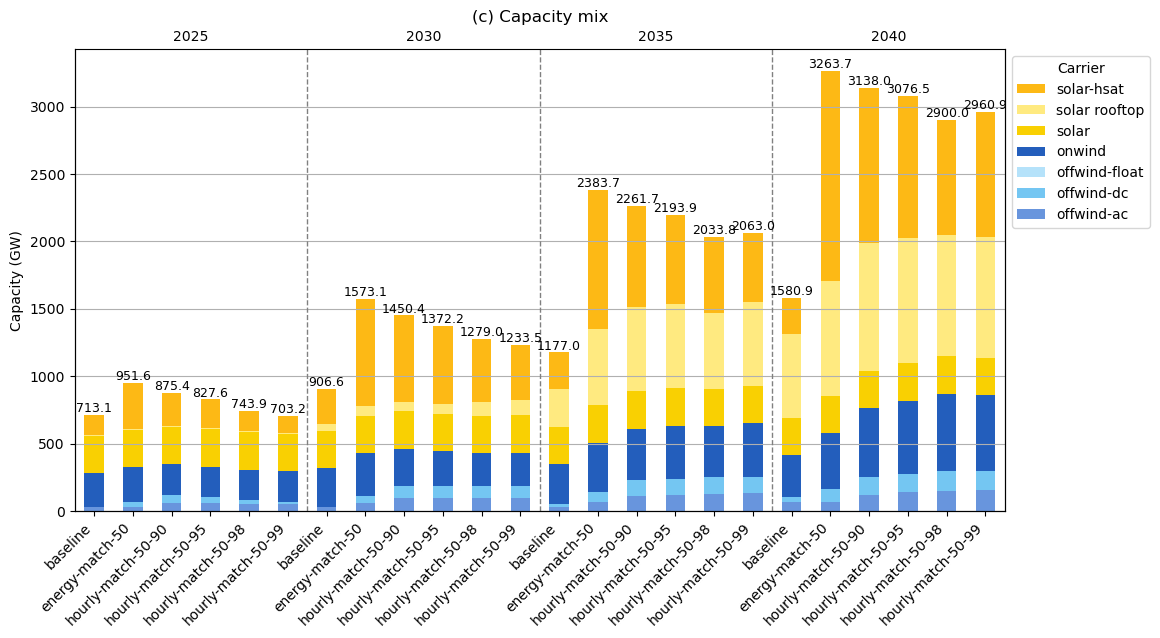

In [8]:
vres_carriers = [
        "solar",
        "solar rooftop",
        "solar-hsat",
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "offwind-float",
    ]
save_fig = False
title_fig = "(c) Capacity mix"
df, colors = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier","bus_carrier"])
df["color"] = colors

df = df[
    df.index.get_level_values("carrier").isin(vres_carriers)
]
df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e3

ax = plot_bar(df, colors, ylabel="Capacity (GW)", title=f"{title_fig}")
if save_fig:
    os.makedirs("figures/system", exist_ok=True)
    ax.figure.savefig(f"figures/system/{title_fig}.png", dpi=300, bbox_inches="tight")

### Optimal capacity vs Max capacity

In [9]:
def get_cap_all(df_all):
    cols = {}
    
    # Get list of years from the index
    all_years = sorted(df_all.index.get_level_values('year').unique())
    
    # Store solar-hsat p_nom_opt from previous years for each scenario
    solar_hsat_history = {}
    solar_hsat_factor = 1.15
    
    for year, sc in df_all.index:
        n = df_all.loc[(year, sc)]
        # Use tuple (year, scenario) as column key instead of network name
        gens = n.generators[n.generators.carrier.isin(vres_carriers) & (n.generators.build_year == year)]
        grouped = gens.groupby("carrier")[["p_nom", "p_nom_opt", "p_nom_max"]].sum()/1e3

        # Add ratio column
        grouped["share over max"] = grouped["p_nom_opt"] / grouped["p_nom_max"]
        
        # Add solar-utility row
        if "solar" in grouped.index and "solar-hsat" in grouped.index:
            solar_utility = pd.Series(index=grouped.columns, dtype=float)
            
            # p_nom_opt: sum of solar and solar-hsat
            solar_utility["p_nom_opt"] = grouped.loc["solar", "p_nom_opt"] + grouped.loc["solar-hsat", "p_nom_opt"] * solar_hsat_factor
            
            # p_nom_max logic
            if year == all_years[0]:  # First year
                # For first year: p_nom_max solar - p_nom solar-hsat
                solar_utility["p_nom_max"] = grouped.loc["solar", "p_nom_max"] - grouped.loc["solar-hsat", "p_nom"] * solar_hsat_factor
            else:
                # For other years: p_nom_max solar (current year) - p_nom_opt solar-hsat (previous year)
                year_idx = all_years.index(year)
                prev_year = all_years[year_idx - 1]
                prev_solar_hsat_opt = solar_hsat_history.get((sc, prev_year), 0)
                solar_utility["p_nom_max"] = grouped.loc["solar", "p_nom_max"] - prev_solar_hsat_opt * solar_hsat_factor
            
            # p_nom: sum of solar and solar-hsat
            solar_utility["p_nom"] = grouped.loc["solar", "p_nom"] + grouped.loc["solar-hsat", "p_nom"]
            
            # share over max
            solar_utility["share over max"] = solar_utility["p_nom_opt"] / solar_utility["p_nom_max"] if solar_utility["p_nom_max"] > 0 else 0
            
            # Concatenate solar-utility to grouped
            grouped = pd.concat([grouped, pd.DataFrame([solar_utility], index=["solar utility"])])
            
            # Store solar-hsat p_nom_opt for next year
            solar_hsat_history[(sc, year)] = grouped.loc["solar-hsat", "p_nom_opt"]
        
        cols[(year, sc)] = round(grouped, 3)

    df = pd.concat(cols, axis=1).fillna(0)
    # Create MultiIndex columns with year and scenario
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=['year', 'scenario', 'capacity'])
    
    # Create carrier-color dictionary
    color_dict = {i: n.carriers.loc["solar" if i == "solar utility" else i, "color"] for i in df.index}
    
    return df, color_dict

year               2025                                                       \
scenario       baseline                           energy-match-50              
capacity      p_nom_opt  p_nom_max share over max       p_nom_opt  p_nom_max   
offwind-ac        7.451    422.687          0.018           7.450    422.687   
offwind-dc        0.001    257.524          0.000          30.724    257.524   
offwind-float     0.001   2231.082          0.000           0.000   2231.082   
onwind           68.573   8632.901          0.008          78.559   8632.901   
solar           123.971  10789.340          0.011         123.970  10789.340   
solar rooftop     7.037   1020.579          0.007           7.053   1020.579   
solar-hsat      146.925   9504.423          0.015         344.706   9504.423   
solar utility   292.935  10789.340          0.027         520.381  10789.340   

year                                                                       \
scenario                     hourly-match-50-90                             
capacity      share over max          p_nom_opt  p_nom_max share over max   
offwind-ac             0.018             31.928    422.687          0.076   
offwind-dc             0.119             59.505    257.524          0.231   
offwind-float          0.000              0.000   2231.082          0.000   
onwind                 0.009             47.505   8632.901          0.006   
solar                  0.011            123.970  10789.340          0.011   
solar rooftop          0.007              7.053   1020.579          0.007   
solar-hsat             0.036            246.305   9504.423          0.026   
solar utility          0.048            407.220  10789.340          0.038   

year                              ...               2040                     \
scenario      hourly-match-50-95  ... hourly-match-50-90 hourly-match-50-95   
capacity               p_nom_opt  ...     share over max          p_nom_opt   
offwind-ac                31.797  ...              0.028             21.462   
offwind-dc                45.078  ...              0.120             19.065   
offwind-float              0.000  ...              0.000              0.013   
onwind                    45.996  ...              0.020            187.792   
solar                    123.970  ...              0.000              6.238   
solar rooftop              7.035  ...              0.826            306.466   
solar-hsat               214.540  ...              0.045            385.827   
solar utility            370.691  ...              0.043            449.939   

year                                                                   \
scenario                                hourly-match-50-98              
capacity       p_nom_max share over max          p_nom_opt  p_nom_max   
offwind-ac       329.420          0.065             24.972    322.153   
offwind-dc       140.558          0.136             21.152    135.569   
offwind-float   2231.082          0.000              0.013   2231.082   
onwind          8461.120          0.022            230.838   8474.077   
solar          10665.532          0.001              8.779  10665.532   
solar rooftop    397.584          0.771            341.119    461.791   
solar-hsat      8842.267          0.044            283.624   8937.527   
solar utility  10571.903          0.043            334.947  10554.801   

year                                                                       
scenario                     hourly-match-50-99                            
capacity      share over max          p_nom_opt  p_nom_max share over max  
offwind-ac             0.078             28.777    319.024          0.090  
offwind-dc             0.156             22.384    136.765          0.164  
offwind-float          0.000              0.013   2231.082          0.000  
onwind                 0.027            202.177   8457.876          0.024  
solar                  0.001              0.004  10665.532       

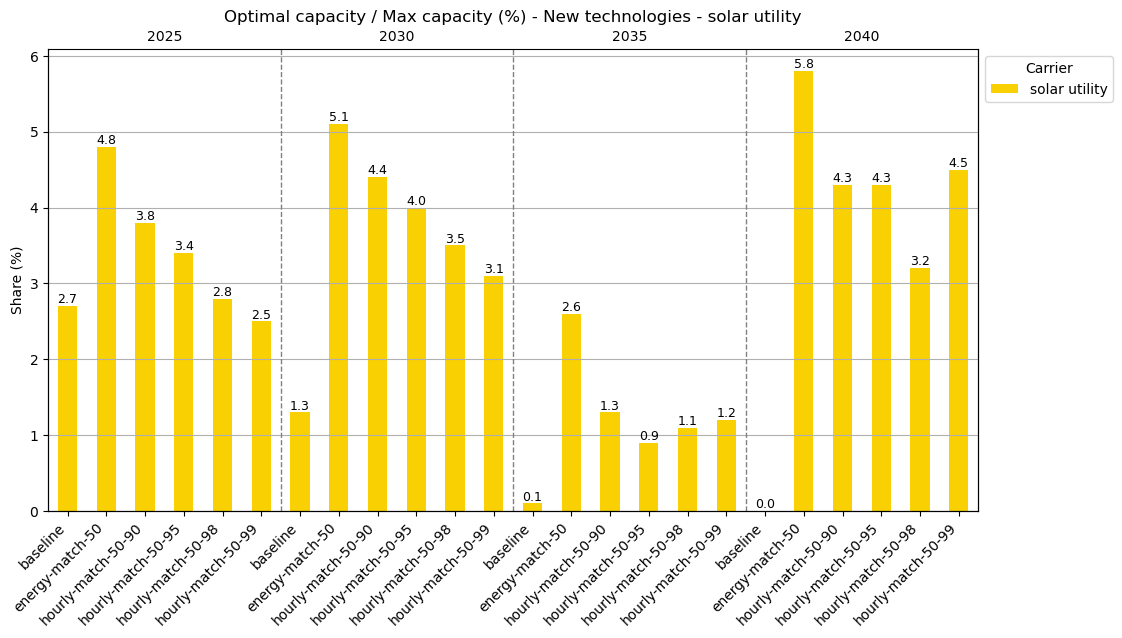

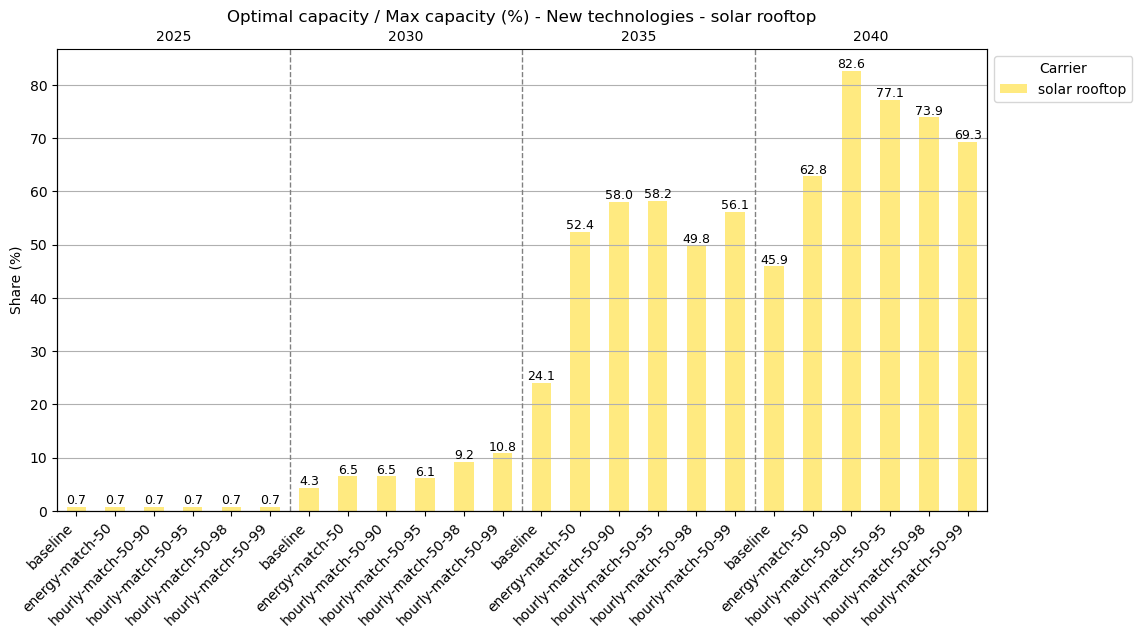

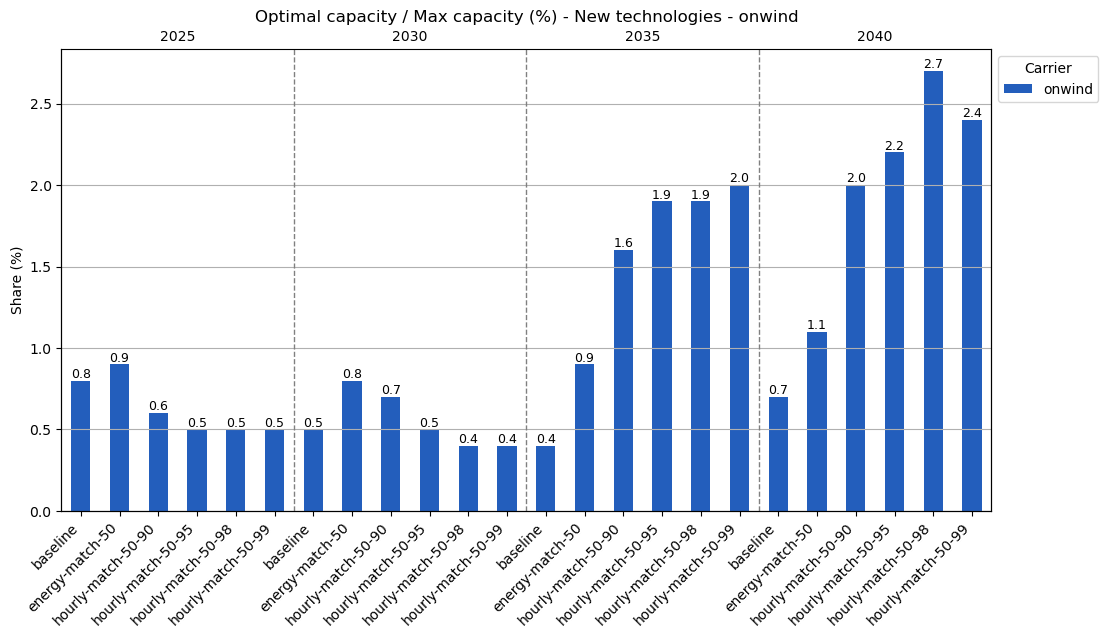

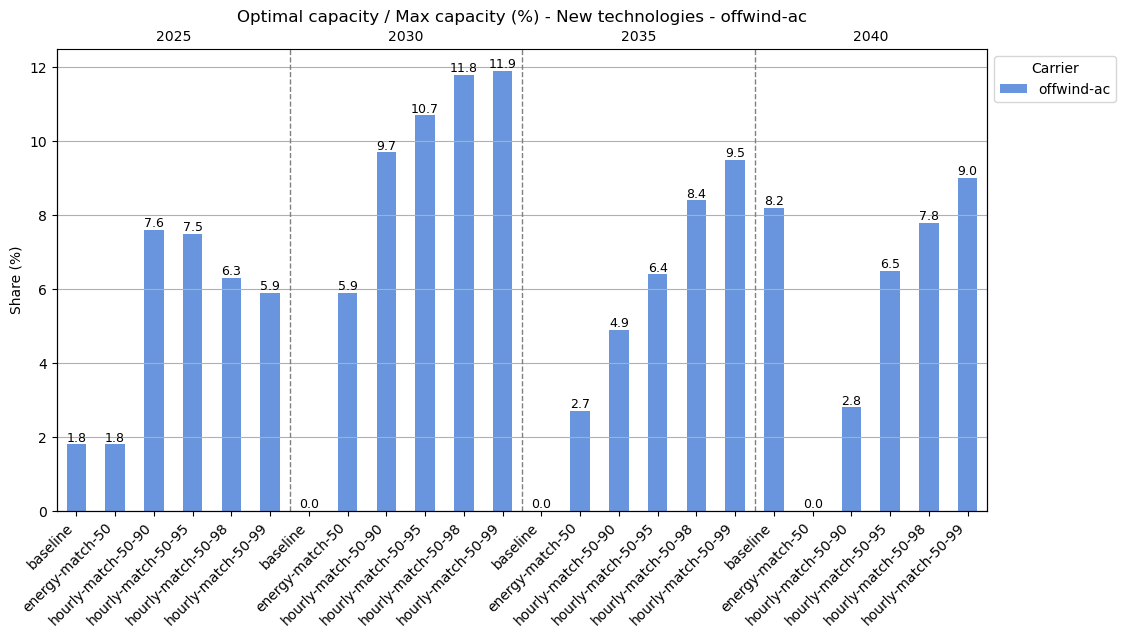

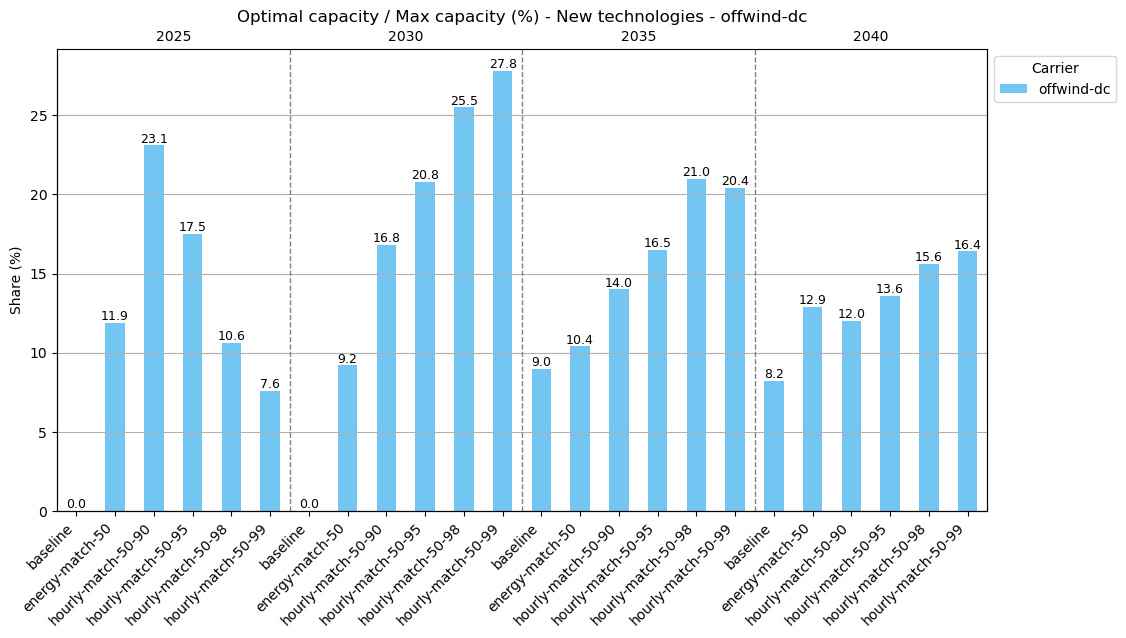

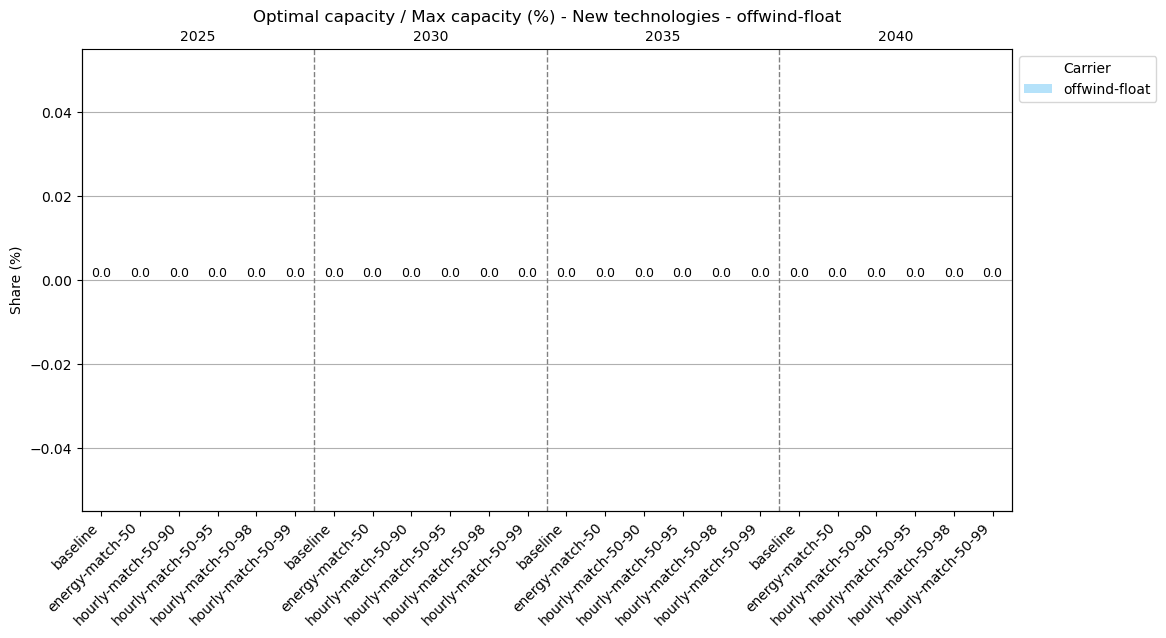

In [10]:
df, colors = get_cap_all(df_networks["network"])
df = df.drop("p_nom", axis=1, level=2)
display(df)
years = df.columns.get_level_values('year').unique()
scenarios = df.columns.get_level_values('scenario').unique()
capacities = df.columns.get_level_values('capacity').unique()

# Use pd.IndexSlice for MultiIndex column selection
idx = pd.IndexSlice
df_plot = df.loc[:, idx[years, scenarios, "share over max"]]
df_plot = df_plot.droplevel('capacity', axis=1)
df_plot = df_plot*100
vres_plot = [
        #"solar",
        "solar utility", # solar + solar-hsat * 1.15 (see add_solar_potential_constraints in solve_network.py)
        "solar rooftop",
        #"solar-hsat",
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "offwind-float",
    ]
for carrier in vres_plot:
    #print("="*40 + f"Analysing {carrier}" + "="*40)
    if carrier not in df_plot.index:
        print(f"Warning: {carrier} not in df_plot index and will be skipped.")
        continue
    ax = plot_bar(df_plot[df_plot.index==carrier], colors[carrier], ylabel="Share (%)", title=f"Optimal capacity / Max capacity (%) - New technologies - {carrier}")

### Access specific years/scenarios/capacities

In [ ]:
years = df.columns.get_level_values('year').unique()
scenarios = df.columns.get_level_values('scenario').unique()
capacities = df.columns.get_level_values('capacity').unique()

# Use pd.IndexSlice for MultiIndex column selection
idx = pd.IndexSlice
df.loc[:, idx[years, "hourly-match-50-99", capacities]]

year                        2025                                        2030  \
scenario      hourly-match-50-99                          hourly-match-50-99   
capacity               p_nom_opt p_nom_max share over max          p_nom_opt   
offwind-ac                 25.15    422.69           0.06              47.48   
offwind-dc                 19.60    257.52           0.08              66.19   
offwind-float               0.00   2231.08           0.00               0.00   
onwind                     46.06   8632.90           0.01              34.79   
solar                     123.97  10789.34           0.01               0.00   
solar rooftop               7.11   1020.58           0.01             109.95   
solar-hsat                122.12   9504.42           0.01             284.67   
solar utility             264.41  10789.34           0.02             327.37   

year                                                 2035            \
scenario                               hourly-match-50-99             
capacity      p_nom_max share over max          p_nom_opt p_nom_max   
offwind-ac       397.60           0.12              33.44    350.72   
offwind-dc       237.93           0.28              34.97    171.74   
offwind-float   2231.08           0.00               0.00   2231.08   
onwind          8599.51           0.00             175.95   8591.93   
solar          10665.37           0.00               0.00  10665.37   
solar rooftop   1013.47           0.11             507.21    903.52   
solar-hsat      9382.30           0.03             105.73   9097.64   
solar utility  10524.93           0.03             121.59  10338.00   

year                                       2040                           
scenario                     hourly-match-50-99                           
capacity      share over max          p_nom_opt p_nom_max share over max  
offwind-ac              0.10              28.78    319.02           0.09  
offwind-dc              0.20              22.38    136.77           0.16  
offwind-float           0.00               0.01   2231.08           0.00  
onwind                  0.02             202.18   8457.88           0.02  
solar                   0.00               0.00  10665.53           0.00  
solar rooftop           0.56             274.67    396.31           0.69  
solar-hsat              0.01             414.18   8991.92           0.05  
solar utility           0.01             476.32  10543.94           0.05

### Debug: Check p_nom_max evolution and brownfield assets

In [ ]:
# Check offwind-ac specifically for baseline scenario
carrier_focus = "offwind-ac"
scenario_focus = "baseline"

print(f"Analyzing {carrier_focus} in {scenario_focus} scenario\n")
print("="*80)

for year in years:
    n = df_networks.loc[(year, scenario_focus), "network"]
    
    # Get all offwind-ac generators
    offwind = n.generators[n.generators.carrier == carrier_focus]
    
    # Separate by extendability
    extendable = offwind[offwind.p_nom_extendable]
    fixed = offwind[~offwind.p_nom_extendable]
    
    print(f"\n{year}:")
    print(f"  Total generators: {len(offwind)}")
    print(f"  - Extendable: {len(extendable)}")
    print(f"  - Fixed (brownfield): {len(fixed)}")
    
    if not extendable.empty:
        print(f"  Extendable assets:")
        print(f"    - p_nom_max total: {extendable.p_nom_max.sum()/1e3:.2f} GW")
        print(f"    - p_nom_opt total: {extendable.p_nom_opt.sum()/1e3:.2f} GW")
        print(f"    - p_nom_min total: {extendable.p_nom_min.sum()/1e3:.2f} GW")
    
    if not fixed.empty:
        print(f"  Fixed (brownfield) assets:")
        print(f"    - p_nom total: {fixed.p_nom.sum()/1e3:.2f} GW")
        print(f"    - Build years: {sorted(fixed.build_year.unique())}")
        
        # Group by build year
        for build_year in sorted(fixed.build_year.unique()):
            cap = fixed[fixed.build_year == build_year].p_nom.sum()/1e3
            print(f"      - From {int(build_year)}: {cap:.2f} GW")

print("\n" + "="*80)
print("\nExpected p_nom_max evolution (if no decommissioning):")
for i, year in enumerate(years[1:], 1):
    prev_year = years[i-1]
    n_prev = df_networks.loc[(prev_year, scenario_focus), "network"]
    n_curr = df_networks.loc[(year, scenario_focus), "network"]
    
    # Get p_nom_opt from previous year (extendable only)
    prev_ext = n_prev.generators[(n_prev.generators.carrier == carrier_focus) & 
                                  (n_prev.generators.p_nom_extendable)]
    prev_installed = prev_ext.p_nom_opt.sum()/1e3
    
    # Get p_nom_max current year
    curr_ext = n_curr.generators[(n_curr.generators.carrier == carrier_focus) & 
                                  (n_curr.generators.p_nom_extendable)]
    curr_max = curr_ext.p_nom_max.sum()/1e3
    
    # Get p_nom_max previous year
    prev_max = prev_ext.p_nom_max.sum()/1e3
    
    expected = prev_max - prev_installed
    actual = curr_max
    difference = actual - expected
    
    print(f"\n{prev_year} → {year}:")
    print(f"  p_nom_max({prev_year}) = {prev_max:.2f} GW")
    print(f"  p_nom_opt({prev_year}) = {prev_installed:.2f} GW")
    print(f"  Expected p_nom_max({year}) = {expected:.2f} GW")
    print(f"  Actual p_nom_max({year}) = {actual:.2f} GW")
    print(f"  Difference = {difference:.2f} GW {'✓' if abs(difference) < 0.01 else '⚠️'}")
    
    # Check if there are decommissioned assets
    n_prev_fixed = n_prev.generators[(n_prev.generators.carrier == carrier_focus) & 
                                      (~n_prev.generators.p_nom_extendable)]
    n_curr_fixed = n_curr.generators[(n_curr.generators.carrier == carrier_focus) & 
                                      (~n_curr.generators.p_nom_extendable)]
    
    if len(n_prev_fixed) != len(n_curr_fixed):
        decommissioned = len(n_prev_fixed) - len(n_curr_fixed)
        print(f"  → {decommissioned} assets decommissioned (lifetime expired)")


Analyzing offwind-ac in baseline scenario


2025:
  Total generators: 64
  - Extendable: 30
  - Fixed (brownfield): 34
  Extendable assets:
    - p_nom_max total: 422.69 GW
    - p_nom_opt total: 7.45 GW
    - p_nom_min total: 7.45 GW
  Fixed (brownfield) assets:
    - p_nom total: 24.92 GW
    - Build years: [2000, 2005, 2010, 2015, 2020]
      - From 2000: 0.06 GW
      - From 2005: 0.60 GW
      - From 2010: 2.24 GW
      - From 2015: 8.06 GW
      - From 2020: 13.95 GW

2030:
  Total generators: 67
  - Extendable: 30
  - Fixed (brownfield): 37
  Extendable assets:
    - p_nom_max total: 415.30 GW
    - p_nom_opt total: 0.00 GW
    - p_nom_min total: 0.00 GW
  Fixed (brownfield) assets:
    - p_nom total: 32.31 GW
    - Build years: [2005, 2010, 2015, 2020, 2025]
      - From 2005: 0.60 GW
      - From 2010: 2.24 GW
      - From 2015: 8.06 GW
      - From 2020: 13.95 GW
      - From 2025: 7.45 GW

2035:
  Total generators: 63
  - Extendable: 30
  - Fixed (brownfield): 33
  Extendabl